In [1]:
import pathlib
import cv2
import numpy as np
import pandas as pd
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras import optimizers

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

c:\Users\Acer\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
train_data = "./Chest-Xray-2/chest_xray/train"
test_data = "./Chest-Xray-2/chest_xray/test"

print(type(train_data))
print(type(test_data))

<class 'str'>
<class 'str'>


In [3]:
train_data = pathlib.Path(train_data)
type(train_data)

pathlib.WindowsPath

In [4]:
test_data = pathlib.Path(test_data)
type(test_data)

pathlib.WindowsPath

In [5]:
train_data.glob("*")

<generator object Path.glob at 0x0000020649CECBF0>

In [6]:
test_data.glob("*")

<generator object Path.glob at 0x0000020649CEDF10>

In [7]:
list(train_data.glob("*"))

[WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA')]

In [8]:
list(test_data.glob("*"))

[WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA')]

In [9]:
list(train_data.glob("NORMAL/*"))

[WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0115-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0117-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0119-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0122-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0125-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0127-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0128-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0129-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0131-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0133-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0135-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0137-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0140-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/NORMAL/IM-0141-0001.

In [10]:
list(train_data.glob("PNEUMONIA/*"))

[WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1000_virus_1681.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1001_bacteria_2932.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1002_bacteria_2933.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1003_bacteria_2934.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1003_virus_1685.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1004_bacteria_2935.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1004_virus_1686.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1005_bacteria_2936.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1005_virus_1688.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/person1006_bacteria_2937.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/train/PNEUMONIA/p

In [11]:
list(test_data.glob("NORMAL/*"))

[WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0001-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0003-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0005-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0006-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0007-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0009-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0010-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0011-0001-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0011-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0013-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0015-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0016-0001.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/NORMAL/IM-0017-0001.jpeg

In [12]:
list(test_data.glob("PNEUMONIA/*"))

[WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_477.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_478.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_480.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_481.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person100_bacteria_482.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person101_bacteria_483.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person101_bacteria_484.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person101_bacteria_485.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person101_bacteria_486.jpeg'),
 WindowsPath('Chest-Xray-2/chest_xray/test/PNEUMONIA/person102_bacteria_487.

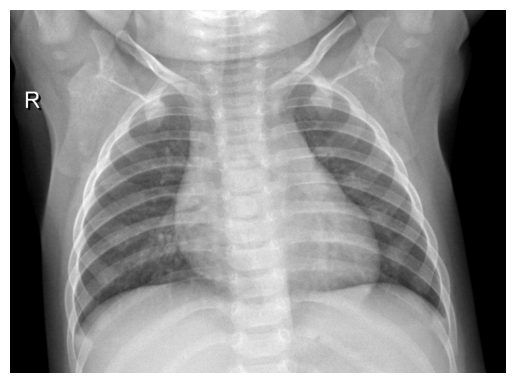

In [13]:
img = cv2.imread(str(list(train_data.glob("NORMAL/*"))[34]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

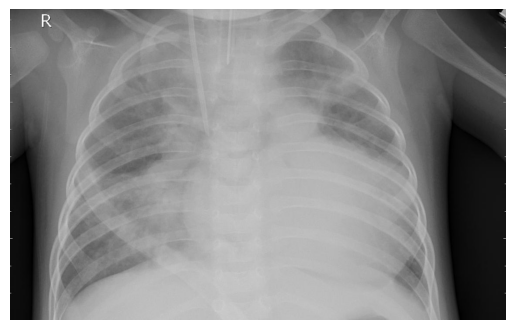

In [14]:
img = cv2.imread(str(list(train_data.glob("PNEUMONIA/*"))[34]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

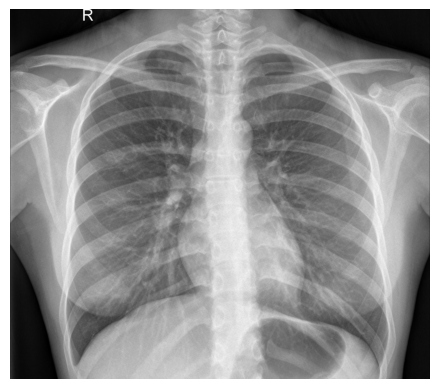

In [15]:
img = cv2.imread(str(list(test_data.glob("NORMAL/*"))[10]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

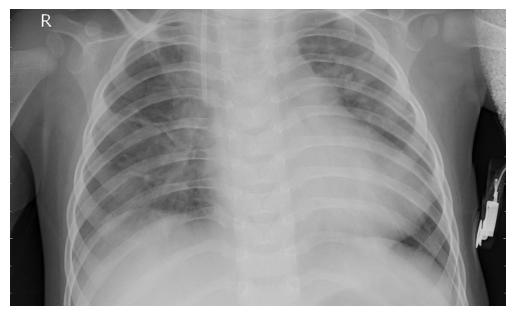

In [16]:
img = cv2.imread(str(list(test_data.glob("PNEUMONIA/*"))[10]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [17]:
print(len(list(train_data.glob("NORMAL/*"))))
print(len(list(train_data.glob("PNEUMONIA/*"))))

1349
3883


imbalanced dataset

In [18]:
print(len(list(test_data.glob("NORMAL/*"))))
print(len(list(test_data.glob("PNEUMONIA/*"))))

234
390


## 1) Custom CNN

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 4187 images belonging to 2 classes.


In [21]:
val_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1045 images belonging to 2 classes.


In [22]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [23]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [25]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.938425925925926), 1: np.float64(0.6738010943031864)}


In [26]:
checkpointer = ModelCheckpoint(
    filepath='custom_cnn_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=4,
    factor=0.2,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [27]:
cnn_model = models.Sequential()

cnn_model.add(layers.Input(shape=(224, 224, 3)))

cnn_model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.BatchNormalization(axis=-1))

cnn_model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.BatchNormalization(axis=-1))

cnn_model.add(layers.Conv2D(16, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.BatchNormalization(axis=-1))

cnn_model.add(layers.Flatten())

cnn_model.add(layers.Dropout(0.5))   

cnn_model.add(layers.Dense(128, activation='relu'))

cnn_model.add(layers.Dropout(0.5))

cnn_model.add(layers.Dense(1, activation='sigmoid')) 

In [28]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 16)     │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,771,153 (6.76 MB)

 Trainable params: 1,770,481 (6.75 MB)

 Non-trainable params: 672 (2.62 KB)

In [29]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [30]:
cnn_history = cnn_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    class_weight=class_weights, 
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7544 - loss: 0.6666 - precision: 0.8847 - recall: 0.7680
Epoch 1: val_loss improved from None to 1.23400, saving model to custom_cnn_best_model.keras

Epoch 1: finished saving model to custom_cnn_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 715s 5s/step - accuracy: 0.8211 - loss: 0.4672 - precision: 0.9269 - recall: 0.8239 - val_accuracy: 0.7426 - val_loss: 1.2340 - val_precision: 0.7426 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8789 - loss: 0.3028 - precision: 0.9601 - recall: 0.8732
Epoch 2: val_loss did not improve from 1.23400
131/131 ━━━━━━━━━━━━━━━━━━━━ 692s 5s/step - accuracy: 0.8856 - loss: 0.2787 - precision: 0.9617 - recall: 0.8809 - val_accuracy: 0.7426 - val_loss: 1.5035 - val_precision: 0.7426 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8968 - loss: 0.2443 - precision:

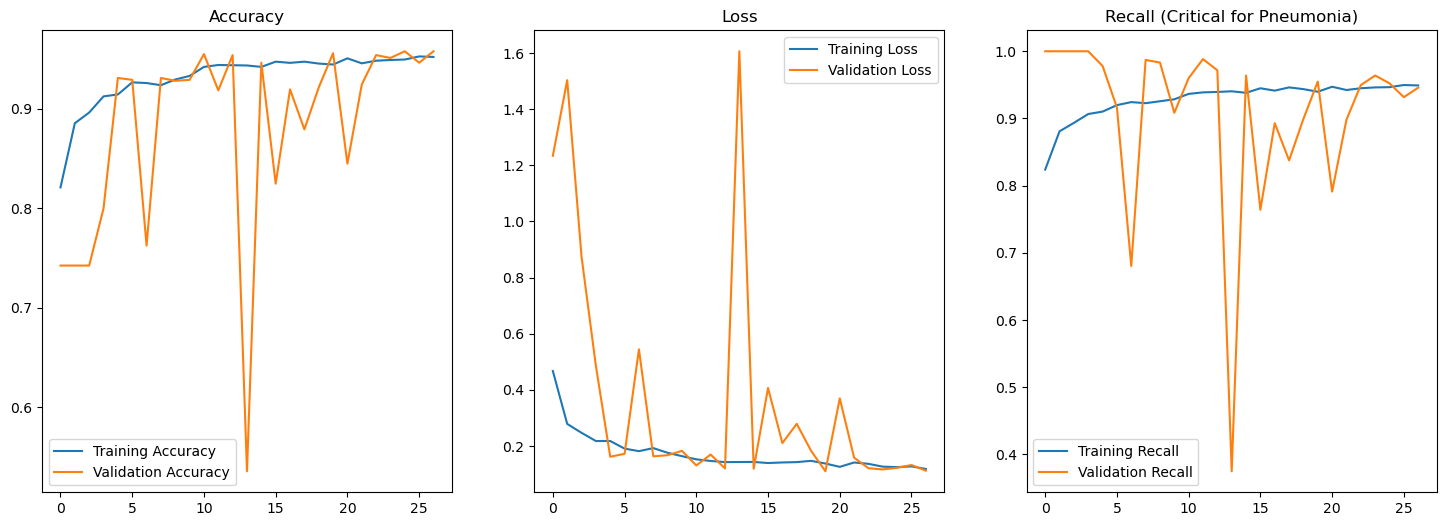

In [ ]:
acc = cnn_history.history['accuracy']
val_acc = cnn_history.history['val_accuracy']

loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']

recall = cnn_history.history['recall']
val_recall = cnn_history.history['val_recall']

precision = cnn_history.history['precision']
val_precision = cnn_history.history['val_precision']

epochs_range = range(len(acc))

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 3, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend()
plt.title('Recall (Critical for Pneumonia)')

plt.show()

>The model shows strong performance with high recall (~0.9+), indicating effective pneumonia detection. 
However, validation fluctuations suggest minor instability due to dataset imbalance and limited validation size.

In [34]:
results = cnn_model.evaluate(test_generator)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 795ms/step - accuracy: 0.8798 - loss: 0.2867 - precision: 0.9134 - recall: 0.8923
Test Loss: 0.28666311502456665
Test Accuracy: 0.879807710647583
Test Precision: 0.913385808467865
Test Recall: 0.892307698726654


>The model achieved ~88% accuracy with high precision (91%) and recall (89%), indicating reliable pneumonia detection with minimal false positives, though slight improvement in recall is needed to reduce missed cases.

In [35]:
y_pred_prob = cnn_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 831ms/step


In [36]:
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

In [37]:
y_true = test_generator.classes

In [38]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL       0.83      0.86      0.84       234
   PNEUMONIA       0.91      0.89      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.88      0.87       624
weighted avg       0.88      0.88      0.88       624



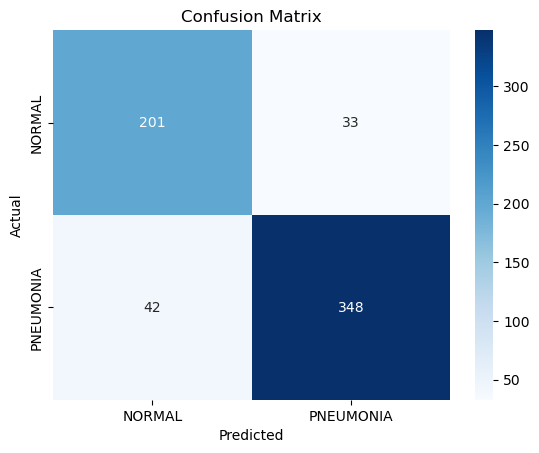

In [41]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The model correctly identifies most pneumonia cases (348 TP) with high precision, but misses 42 cases (FN), indicating the need to improve recall for safer medical predictions.

>The confusion matrix shows strong performance with high true positives and low false positives. However, false negatives are critical in medical diagnosis, and reducing them is a key area for improvement.